In [131]:
import sys
sys.path.append('../SlitMaker')
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib as mpl
import matplotlib.image as mpimg
from matplotlib.collections import LineCollection
%matplotlib inline
from scipy.optimize import curve_fit
from scipy.optimize import minimize_scalar
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.modeling.models import BlackBody
from astropy.constants import c
from astropy import units as u
from astropy.units import photometric
from synphot import SourceSpectrum, Observation, SpectralElement
from synphot.units import VEGAMAG
import slitoverlaymaker
import overlayfunction
import math
import os

1292.2051


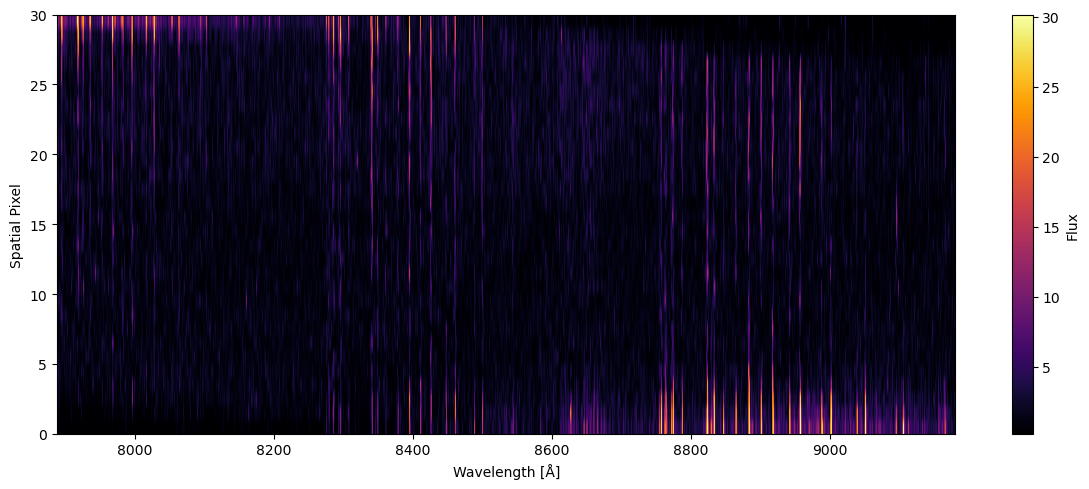

In [129]:
filename = "./spec2dkdg63/jan2019/slit.KDG63A.057R.fits.gz"
with fits.open(filename) as hdul:
    flux = hdul[1].data[0]['FLUX']   # shape: (66, 4096)
    wavelength = hdul[1].data[0]['LAMBDA0']  # shape: (4096,) 
    # Define axis extents
    extent = [wavelength[0], wavelength[-1], 0, flux.shape[0]]  # [Xmin, Xmax, Ymin, Ymax]
    valid = flux[flux > 0]
    print(wavelength[-1]-wavelength[0])
    a_min = np.percentile(valid, 5)
    a_max = np.percentile(valid, 99)
    clipped = np.clip(flux, a_min, a_max)
    # Plot
    plt.figure(figsize=(12, 5))
    plt.imshow(clipped, aspect='auto', cmap='inferno', origin='lower', extent=extent)
    plt.xlabel("Wavelength [Å]")
    plt.ylabel("Spatial Pixel")
    plt.colorbar(label="Flux")
    plt.tight_layout()
    plt.show()

In [145]:
folder = "./spec2dkdg63/jan2019/"
prefix = "slit.KDG63A."
suffix = "R.fits.gz"
file_ids = range(13, 58)

flux_list = []
shapes = []

# Load and record shapes
for fid in file_ids:
    fname = os.path.join(folder, f"{prefix}{fid:03d}{suffix}")
    if not os.path.exists(fname):
        print(f"File not found: {fname}")
        continue

    with fits.open(fname) as hdul:
        try:
            flux = hdul[1].data[0]['FLUX']
            flux_list.append(flux)
            shapes.append(flux.shape)
            print(flux.shape, fname)
        except Exception as e:
            print(f"Error reading FLUX from {fname}: {e}")

# Find common minimum shape
min_shape = tuple(np.min(shapes, axis=0))
print(f"Minimum common shape: {min_shape}")

# Crop all flux arrays to this shape
flux_cropped = [f[:min_shape[0], :min_shape[1]] for f in flux_list]


(61, 4096) ./spec2dkdg63/jan2019/slit.KDG63A.013R.fits.gz
(30, 4096) ./spec2dkdg63/jan2019/slit.KDG63A.014R.fits.gz
(41, 4096) ./spec2dkdg63/jan2019/slit.KDG63A.015R.fits.gz
(51, 4096) ./spec2dkdg63/jan2019/slit.KDG63A.016R.fits.gz
(26, 4096) ./spec2dkdg63/jan2019/slit.KDG63A.017R.fits.gz
(19, 4096) ./spec2dkdg63/jan2019/slit.KDG63A.018R.fits.gz
(54, 4096) ./spec2dkdg63/jan2019/slit.KDG63A.019R.fits.gz
(65, 4096) ./spec2dkdg63/jan2019/slit.KDG63A.020R.fits.gz
(37, 4096) ./spec2dkdg63/jan2019/slit.KDG63A.021R.fits.gz
(36, 4096) ./spec2dkdg63/jan2019/slit.KDG63A.022R.fits.gz
File not found: ./spec2dkdg63/jan2019/slit.KDG63A.023R.fits.gz
(34, 4096) ./spec2dkdg63/jan2019/slit.KDG63A.024R.fits.gz
File not found: ./spec2dkdg63/jan2019/slit.KDG63A.025R.fits.gz
(70, 4096) ./spec2dkdg63/jan2019/slit.KDG63A.026R.fits.gz
(39, 4096) ./spec2dkdg63/jan2019/slit.KDG63A.027R.fits.gz
(30, 4096) ./spec2dkdg63/jan2019/slit.KDG63A.028R.fits.gz
(53, 4096) ./spec2dkdg63/jan2019/slit.KDG63A.029R.fits.gz
(19,